# **1. 손글씨 도형**
- 손으로 그린 원, 삼각형, X 이미지를 CNN으로 분류
- 데이터 구성: 학습 데이터 240장, 테스트 60장, 3개의 클래스가 균등하게 구성

In [1]:
# 이 노트북에서 사용할 라이브러리를 불러온다.
# torch: 텐서·신경망 학습, torchvision: 이미지 데이터·전처리 도구를 제공한다.
# random과 numpy는 다음 셀에서 난수 시드를 고정할 때 사용한다.
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import zipfile
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from pathlib import Path


In [2]:
# 난수 시드를 고정한다.
# 데이터 순서, 이미지 증강, 모델 가중치 초기화에 무작위 요소가 있으므로
# 같은 조건에서 실험을 다시 실행하고 결과를 비교하기 쉬워진다.
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
# 압축을 풀어 둘 data 폴더를 준비한다.
# 이미 폴더가 있다면 다시 만들지 않아 기존 파일을 유지한다.
extract_dir = Path("./data")
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True)


In [4]:
# 제공된 shape.zip 파일의 내용을 data 폴더에 압축 해제한다.
# with 블록이 끝나면 zip 파일을 자동으로 닫아 준다.
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall("./data")


In [5]:
# 학습용·테스트용 이미지 폴더 경로를 Path 객체로 만든다.
# Path를 사용하면 운영체제별 경로 구분자를 직접 신경 쓰지 않아도 된다.
shape_root = extract_dir / 'shape'
train_dir = shape_root / 'train'
test_dir = shape_root / 'test'
print('학습 경로: ', train_dir)
print('테스트 경로: ', test_dir)


학습 경로:  data/shape/train
테스트 경로:  data/shape/test


# **2. ImageFolder**
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함

In [6]:
# ImageFolder는 하위 폴더 이름을 클래스 이름으로 사용한다.
# 클래스 번호는 폴더 이름의 알파벳순으로 정해지므로 cir=0, tri=1, x=2가 된다.
# 아직 transform을 전달하지 않았으므로 여기서는 데이터 구성과 클래스 정보만 확인한다.
# cir(0), tri(1), x(2)
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)

print('클래스: ', raw_train.classes)
print('클래스 번호: ', raw_train.class_to_idx)
print('학습 데이터 이미지 수: ', len(raw_train))
print('테스트 데이터 이미지 수: ', len(raw_test))


클래스:  ['cir', 'tri', 'x']
클래스 번호:  {'cir': 0, 'tri': 1, 'x': 2}
학습 데이터 이미지 수:  240
테스트 데이터 이미지 수:  60


# **3. 전처리와 데이터 증강**
- 모든 이미지를 28x28 1채널 흑백으로 통일함
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖게 함
- 픽셀 값을 텐서로 바꾼 뒤, 평균 0.5, 표준편차 0.5로 정규화
- 일반화 성능을 높이기 위해 학습 데이터에만 회전/이동/크기 등을 변화

In [7]:
# transforms.Compose는 아래 전처리·증강 단계를 위에서 아래 순서로 적용한다.
# 학습용에는 무작위 변형을 추가하지만, 평가용에는 같은 입력을 유지하기 위해 넣지 않는다.
train_transform = transforms.Compose([
    # 모든 이미지를 28 x 28 크기로 통일한다.
    transforms.Resize((28, 28)),
    # RGB 등 입력 형태와 관계없이 흑백 채널 1개로 변환한다.
    transforms.Grayscale(num_output_channels=1),
    # p=1.0이므로 무작위가 아닌 항상 색을 반전한다.
    transforms.RandomInvert(p=1.0),
    # 학습 때만 회전·이동·확대/축소를 적용해 다양한 도형을 학습한다.
    transforms.RandomAffine(
        degrees=12,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10),
    ),
    # PIL 이미지를 float32 텐서로 바꾸고 일반적인 8비트 픽셀값을 0~1로 스케일한다.
    transforms.ToTensor(),
    # (x - 0.5) / 0.5를 적용해 0.5가 0이 되도록 값을 대략 -1~1 범위로 바꾼다.
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

eval_transform = transforms.Compose([
    # 검증·테스트에는 결과가 매번 달라지지 않도록 무작위 증강을 적용하지 않는다.
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    # 학습 데이터와 같은 색상 방향을 유지하기 위해 항상 반전한다.
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])



# **4. 학습/검증/테스트 데이터 분리**
- 학습 데이터: 가중치를 실제로 업데이트
- 검증 데이터: 학습 중 모델 선택과 과적합 확인에 사용
- 테스트 데이터: 모든 학습과 모델 선택이 끝난 뒤, 최종 성능을 확인

In [8]:
# transform 없이 데이터셋을 한 번 더 만들어 클래스 정보와 원본 레이블을 확인한다.
# base_dataset은 학습·검증 인덱스를 클래스별로 나누는 기준으로만 사용한다.
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes


3

In [9]:
# targets는 각 이미지 파일에 연결된 정답 클래스 번호의 목록이다.
# 예: cir 폴더의 이미지는 0, tri는 1, x는 2로 저장된다.
print(base_dataset.targets)


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [10]:
# np.where는 조건을 만족하는 위치(인덱스)를 찾는다.
# 전체 학습 데이터 중 레이블이 0인 원 이미지의 인덱스만 확인한다.
np.where(np.array(base_dataset.targets) == 0)[0]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79])

In [11]:
# 각 클래스의 인덱스를 따로 섞은 뒤 80%는 학습, 20%는 검증으로 나눈다.
# 이렇게 나누면 세 도형의 비율이 두 데이터셋에 비슷하게 유지된다.
# 같은 파일을 쓰되 학습에는 증강 transform, 검증에는 고정 transform을 적용한다.
train_indices = []
val_indices = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0] # base_dataset.targets => labels 의미
    rng.shuffle(indices)
    split = int(len(indices) * 0.8)
    train_indices.extend(indices[:split].tolist()) # train data 생성
    val_indices.extend(indices[split:].tolist())   # validate data 생성
    
train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# 기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 생성
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print('학습: ', len(train_dataset))    
print('검증: ', len(val_dataset))    
print('테스트: ', len(test_dataset))    


학습:  192
검증:  48
테스트:  60


In [12]:
# DataLoader는 데이터셋을 batch_size개씩 묶어 모델에 전달한다.
# 학습 데이터만 shuffle=True로 섞고, 검증·테스트는 항상 같은 순서로 평가한다.
# pin_memory는 CUDA GPU로 데이터를 옮길 때 전송 성능에 도움을 줄 수 있다.
BATCH_SIZE = 32

# pin_memory=True
# CPU의 일반적인 메모리를 Pageable Memory라고 하고, GPU 전송에 유리하도록
# 고정된 CPU 메모리를 Pinned Memory라고 한다.
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

# **5. 이미지와 텐서 모양 확인**

- CNN 입력 텐서 : [배치, 채널, 높이, 너비]
- 현재 데이터의 배치 shape: [32, 1, 28, 28]

In [13]:
# DataLoader에서 첫 번째 배치를 하나 꺼내 CNN에 넣을 입력 형태를 확인한다.
# CNN 입력은 [배치 수, 채널 수, 높이, 너비] 순서를 사용한다.
images, labels = next(iter(train_loader))
print('이미지 배치: ', images.shape)
print('레이블 배치: ', labels.shape)


이미지 배치:  torch.Size([32, 1, 28, 28])
레이블 배치:  torch.Size([32])


/Users/songjeong-geun/Desktop/KDT/10_MLDL/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [14]:
# 정규화된 이미지를 화면에 표시할 때 원래 0~1 밝기 범위로 되돌리는 함수다.
# Normalize(mean=0.5, std=0.5)의 역연산은 image * 0.5 + 0.5다.
def denormalize(image):
    return image * 0.5 + 0.5

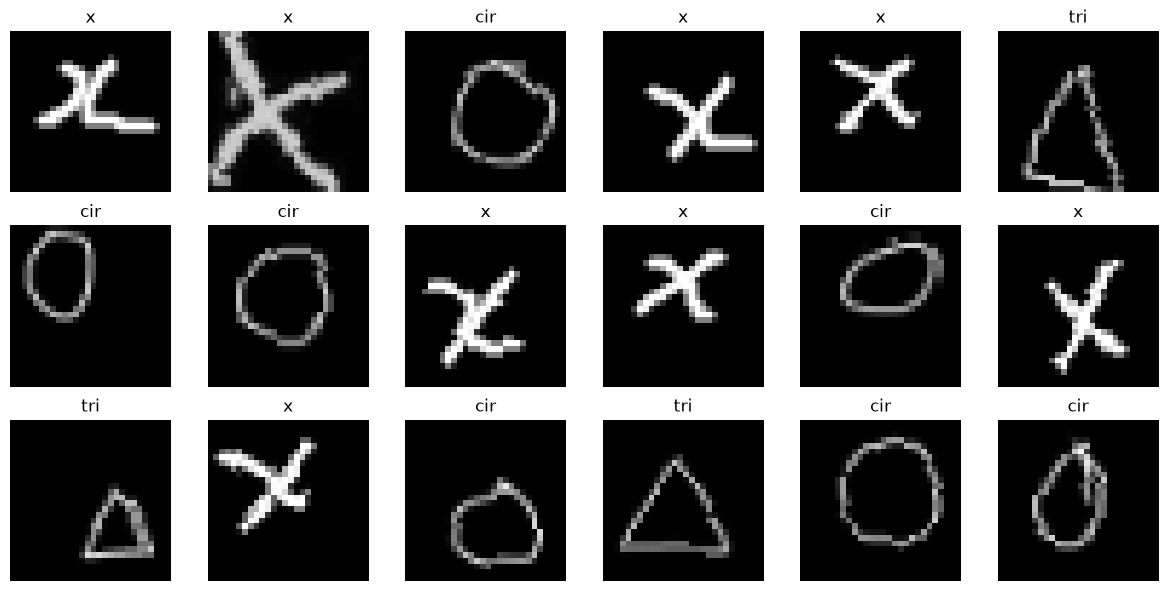

In [15]:
# 증강과 정규화를 거친 학습 이미지 18장을 직접 확인한다.
# squeeze(0)는 흑백 채널 차원 [1, H, W]에서 1을 제거해 Matplotlib이 읽을 [H, W]로 만든다.
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()


# **6. CNN 모델**

### BatchNorm2d
BatchNorm2d는 각 채널(feature map)의 값 분포를 정돈해 학습을 더 안정적으로 돕는다.

```
입력 이미지 > Conv2d > 32개의 Feature Map 생성 > BatchNorm2d > 각 Feature Map의 값들을 정규화 > ReLU
nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
nn.BatchNorm2d(32), # 32: 채널 수
nn.ReLU()
```

> CNN의 Conv2d를 통과하면 값들이 여러가지로 변함. 처음 입력 이미지가 어느 정도 정규화되어 있어도 Conv2d를 통과하고 나면 가중치와 계산되면서 채널마다 값의 분포가 달라질 수 있음. BatchNorm은 값을 어느 정도 정돈해서 다음층으로 보내주는 역할을 함

### AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마이든 상관없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어
- CNN에서 분류 모델의 마지막 부분에 자주 사용

```
nn.AvgPool2d(kernel_size=2)

1 3 2 4
5 7 6 8
2 4 1 3
6 8 5 7

2x2의 평균을 계산 > (1+3+5+7)/4 = 4

nn.AdaptiveAvgPool2d((1, 1))
입력 크기가 어떻게 생겼든 최종적으로 1x1로 만들어줘!

1 2
3 4

(1+2+3+4)/4 = 2.5
Feature Map 하나를 대표하는 값 하나가 만들어짐
```
```
예)
Conv2d를 통과해서 Feature Map이 64개일 경우
[32, 64, 14, 14]
nn.AdaptiveAvgPool2d((1, 1)) # 실제로 Feature Map 의 개수를 1개로 합치는건 아니다.
[32, 64, 1, 1]
```

> 채널 개수는 그대로 유지되고, H,W 만 줄여줌

### Dropout
- 신경망이 학습할 때 일부 뉴런을 일부러 랜덤하게 꺼버리는 기법
- 과적합을 줄이기 위해 사용
- 네트워크에서 뉴런을 영구적으로 삭제하는 것이 아니며, 학습 순간에만 뉴런의 출력을 0으로 함
- model.train()시 Dropout 작동, model.eval()에는 Dropout이 꺼짐
- model.train() 모드에서는 Dropout이 작동하고, model.eval() 모드에서는 작동하지 않음


In [16]:
# ShapeCNN은 특징 추출부(features)와 분류부(classifier)를 분리한 CNN 모델이다.
# Conv2d와 MaxPool2d로 도형의 공간적 특징을 추출한 뒤, 최종적으로 세 클래스의 logit을 출력한다.
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()  # 부모(nn.Module)의 생성자 호출
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            # 3x3 합성곱을 연속 적용해 특징을 단계적으로 추출하고 비선형 변환을 늘린다.
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            # inplace=True는 입력 활성화 텐서를 재사용해 메모리를 약간 절약할 수 있다.
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            # inplace=True는 입력 활성화 텐서를 재사용해 메모리를 약간 절약할 수 있다.
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, num_classes) # 64 : (최종 출력 텐서의 채널 수) * Height * Width = 64 * 1 * 1
        )
        
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [17]:
# 사용 가능한 가속 장치를 우선순위대로 선택한다.
# NVIDIA GPU는 cuda, Apple Silicon GPU는 mps를 사용하며 둘 다 없으면 cpu에서 실행한다.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')
    
print(DEVICE)


mps


In [18]:
# 클래스 수에 맞게 모델을 만들고, 앞에서 선택한 DEVICE(CPU/GPU) 메모리로 옮긴다.
# to(DEVICE)를 한 뒤에는 입력 텐서와 레이블도 같은 장치로 옮겨야 한다.
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model


ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [19]:
# CrossEntropyLoss는 다중 분류용 손실 함수다.
# 모델이 출력한 softmax 이전 점수(logit)와 정답 클래스 번호를 받아 손실을 계산한다.
criterion = nn.CrossEntropyLoss()

### AdamW
- Adam에 가중치 감쇠(Weight Decay)를 적용한 방식 
- 딥러닝 모델의 가중치가 지나치게 커지면 학습 데이터에 너무 맞춰지는 과적합이 발생할 수 있음 > Weight Decay로 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법을 사용
- 과적합을 줄이고 일반화 성능을 높이도록 만듦

```
Gradient > Adam의 적응적 계산 > 가중치 업데이트 > Weight Decay를 적용(L2 규제)
```



In [20]:
# AdamW는 학습률을 상황에 맞게 조절하는 Adam에 weight decay를 더한 옵티마이저다.
# weight_decay는 가중치가 과도하게 커지는 것을 완화해 과적합을 줄이는 데 도움을 준다.
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4) # 1e-3 = 0.001


### Scheduler
- 검증 성능이 더 이상 좋아지지 않을 때 자동으로 학습률을 낮춰주는 기능
- 가중치 = 가중치 - 학습률 * 기울기

```
1 Epoch : DataLoader 한 바퀴 (전체 학습 데이터를 한 번 사용)
Epoch1 Loss : 0.8
Epoch2 Loss : 0.6
Epoch3 Loss : 0.5
Epoch4 Loss : 0.43
Epoch5 Loss : 0.40 # 이후로 Loss가 좋아지지 않음
Epoch6 Loss : 0.41
Epoch7 Loss : 0.42
Epoch8 Loss : 0.40
```

- mode: 무엇을 기준으로 좋아졌다고 판단할지를 결정 // min : Loss값이 작을수록 좋다고 판단
- facotr: 학습률을 설정 값
- patience: 몇 번까지 참아줄 것인지 설정


In [ ]:
# 검증 손실이 patience 횟수만큼 개선되지 않으면 학습률을 절반(factor=0.5)으로 낮춘다.
# 손실은 작을수록 좋으므로 mode='min'을 사용한다.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)


### 학습과 평가 함수

In [22]:
# 한 epoch 동안 학습 또는 평가를 수행하고 평균 손실·정확도를 반환하는 함수다.
# optimizer가 전달되면 학습 모드에서 역전파·가중치 업데이트를 수행하고,
# 전달되지 않으면 평가 모드에서 기울기 계산 없이 성능만 측정한다.
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    # enable_grad: 기울기 계산을 활성화
    # inference_mode: 메모리 사용량을 감소. 불필요한 기울기 계산 방지. 실행 속도 향상
    context = torch.enable_grad() if is_training else torch.inference_mode()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if is_training:
                # 기울기 값을 0으로 채우는 대신 None으로 설정
                # 메모리 사용을 줄일 수 있음. 불필요한 0 탠서 생성을 줄임
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size
    return total_loss / total_samples, total_correct / total_samples    
        


### 모델 학습과 Early Stopping
- 검증 손실이 가장 낮을 때의 가중치를 저장
- 일정 횟수 동안 검증 손실이 개선되지 않으면 학습을 조기에 종료하여 과적합과 불필요한 학습을 줄임

In [23]:
# 학습 횟수, 조기 종료 기준, 최고 검증 성능과 학습 기록을 초기화한다.
# best_val_loss보다 검증 손실이 낮아질 때만 모델 가중치를 저장한다.
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8 
best_val_loss = float('inf')
wait = 0
history = {"train_loss":[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_model_path = 'best_shape_cnn.pth'


In [26]:
# 아래는 학습 루프를 호출하는 기본 형태다.
# 주석을 해제하면 매 epoch마다 학습 데이터로 가중치를 갱신한 뒤 검증 성능을 측정한다.
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, DEVICE, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(
            f'Epoch {epoch:02d}/{EPOCHS} | '
            f'train loss {train_loss:.4f}, acc {train_acc*100:6.2f}% | '
            f'val loss {val_loss:.4f}, acc {val_acc*100:6.2f}% | '
            f'lr {current_lr:.6f}'
    )
    
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= EARLY_STOPPING_PATIENCE:
            print('검증 손실이 더 이상 개선되지 않아 학습을 종료합니다.')
            break
    

/Users/songjeong-geun/Desktop/KDT/10_MLDL/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/50 | train loss 0.7839, acc  59.38% | val loss 1.0383, acc  37.50% | lr 0.001000
Epoch 02/50 | train loss 0.5802, acc  73.44% | val loss 0.8260, acc  66.67% | lr 0.001000
Epoch 03/50 | train loss 0.5170, acc  80.21% | val loss 0.7315, acc  77.08% | lr 0.001000
Epoch 04/50 | train loss 0.4837, acc  78.12% | val loss 0.6815, acc  66.67% | lr 0.001000
Epoch 05/50 | train loss 0.4600, acc  81.25% | val loss 0.6150, acc  66.67% | lr 0.001000
Epoch 06/50 | train loss 0.4250, acc  80.21% | val loss 0.4898, acc  77.08% | lr 0.001000
Epoch 07/50 | train loss 0.3521, acc  91.15% | val loss 0.4693, acc  79.17% | lr 0.001000
Epoch 08/50 | train loss 0.3345, acc  87.50% | val loss 0.3440, acc  83.33% | lr 0.001000
Epoch 09/50 | train loss 0.3467, acc  86.98% | val loss 0.3208, acc  89.58% | lr 0.001000
Epoch 10/50 | train loss 0.2809, acc  92.71% | val loss 0.4475, acc  75.00% | lr 0.001000
Epoch 11/50 | train loss 0.2534, acc  92.71% | val loss 0.2226, acc  93.75% | lr 0.001000
Epoch 12/5

# **7. 학습 곡선으로 과적합 확인**
- 학습 손실과 검증 손실이 함께 감소하면 정상적인 학습에 가까움
- 학습 손실은 계속 감소하지만, 검증 손실이 증가하면 과적합 가능성이 큼
- 학습/검증 정확도가 모두 낮으면 모델 용량, 전처리, 학습률, 데이터 품질 등을 점검해야 함

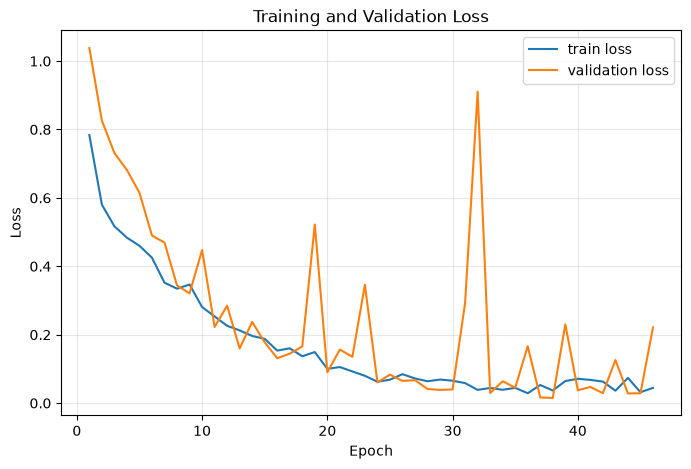

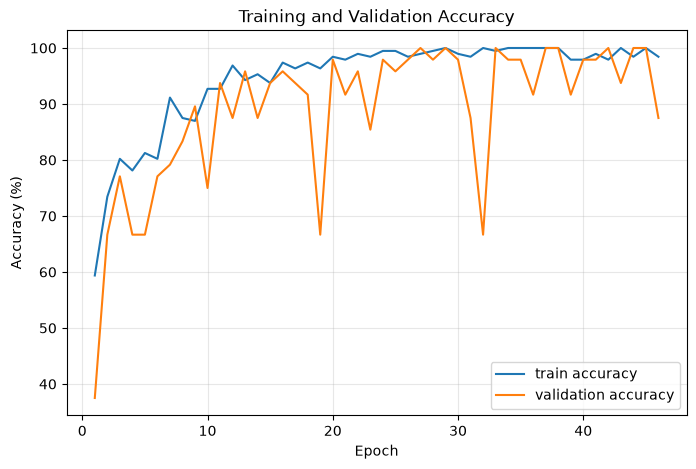

In [27]:
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history['train_loss'], label='train loss')
plt.plot(epochs_ran, history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, np.array(history['train_acc']) * 100, label='train accuracy')
plt.plot(epochs_ran, np.array(history['val_acc']) * 100, label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **8. 학습된 모델로 테스트 평가**

### 학습되지 않은 모델로 테스트 평가

In [28]:
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [29]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc: {test_acc * 100:.2f}%')

/Users/songjeong-geun/Desktop/KDT/10_MLDL/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


테스트 Loss: 1.1005
테스트 acc: 33.33%


### 가중치를 불러와 모델에 적용한 후 테스트 평가

In [ ]:
model = ShapeCNN(num_classes).to(DEVICE)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))

# All keys matched successfully 메시지가 나오는 이유: 저장된 파일의 모든 파라미터 이름이 현재 모델의 구조와 완벽히 일치한다는 것을 의미

<All keys matched successfully>

In [31]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc: {test_acc * 100:.2f}%')

/Users/songjeong-geun/Desktop/KDT/10_MLDL/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


테스트 Loss: 0.0198
테스트 acc: 100.00%


# **9. 혼동행렬과 클래스별 성능**
- 전체 정확도가 높아도 특정 클래스만 자주 틀릴 수 있음
- 혼동행렬은 실제 클래스와 예측 클래스의 조합을 볼 수 있음
- 대각선 값이 클수록 올바르게 분류한 이미지가 많다는 뜻

In [32]:
def collect_predictions(model, loader):
    # 검증 테스트 모델로 돌림
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.inference_mode():
        for images, labels in loader:
            logits = model(images.to(DEVICE))
            probs = torch.softmax(logits, dim=1).cpu()
            preds = probs.argmax(dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
            all_probs.append(probs)

    return (
        torch.cat(all_images),
        torch.cat(all_labels),
        torch.cat(all_preds),
        torch.cat(all_probs),
    )

In [33]:
test_images, y_true, y_pred, y_prob = collect_predictions(model, test_loader)

/Users/songjeong-geun/Desktop/KDT/10_MLDL/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [34]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

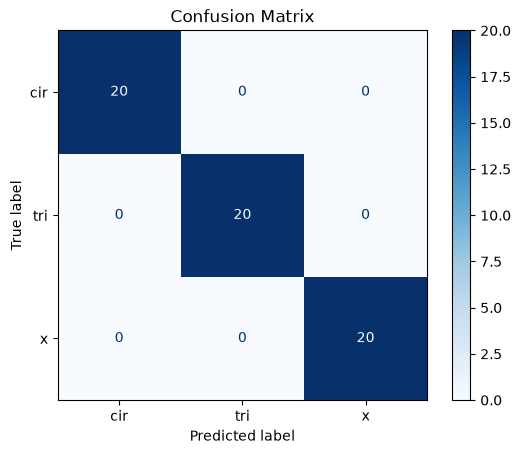

In [36]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(
    y_true.numpy(),
    y_pred.numpy(),
    target_names=class_names,
    digits=4,
    zero_division=0,
))
# precision : 모델이 True로 분류한 것중 실제로 True인 비율
# recall : 실제 해당 클래스 중에서 모델이 찾아낸 비율
# f1-score : precision, recall 조합 평균
# support : 클래스의 개수
# macro avg : 다중 분류 모델에서 각 클래스별 성능 지표(정밀도, 재현율, F1 스코어 등)를 먼저 구한 뒤, 데이터 개수와 상관없이 모든 클래스의 값을 단순 산술 평균하는 방식
# weighted avg : 가중 산술 평균은 자료의 평균을 구할 때 자료 값의 중요도나 영향 정도에 해당하는 가중치를 반영하여 구한 평균값이다. 모든 가중치가 동일할 경우, 가중 평균은 산술 평균과 동일

              precision    recall  f1-score   support

         cir     1.0000    1.0000    1.0000        20
         tri     1.0000    1.0000    1.0000        20
           x     1.0000    1.0000    1.0000        20

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0000    1.0000    1.0000        60

